In [ ]:
#doing the imports

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#reimporting the main features

tickers = ["SPY", "QQQ", "TLT", "GLD", "XLE"]

prices = yf.download(
    tickers,
    start="2015-01-01",
    end="2026-01-01",
    auto_adjust=True
)["Close"]

log_returns = np.log(prices / prices.shift(1)).dropna()

[*********************100%***********************]  5 of 5 completed


In [ ]:
#redoing the equations and setting a random example

mean_returns = log_returns.mean()
covariance_matrix = log_returns.cov()
weights = np.array([
    0.30,
    0.20,
    0.20,
    0.15,
    0.15
])

In [ ]:
#simulating the returns for a day
simulated_returns = np.random.multivariate_normal(
    mean_returns,
    covariance_matrix
)
print(simulated_returns)

[ 0.00767662 -0.00326015 -0.00159279  0.01016254  0.00616077]


In [ ]:
#turning our simulated day's returns into a portfolio

portfolio_return = weights @ simulated_returns

print(portfolio_return)

0.0037808962053196833


In [ ]:
#now we simulate 10000 days

n_simulations = 100000
simulated_returns = np.random.multivariate_normal(
    mean_returns,
    covariance_matrix,
    size=n_simulations
)

In [ ]:
#caluclating the portfolio retursn

simulated_portfolio_returns = simulated_returns @ weights
print(simulated_portfolio_returns.shape)

(100000,)


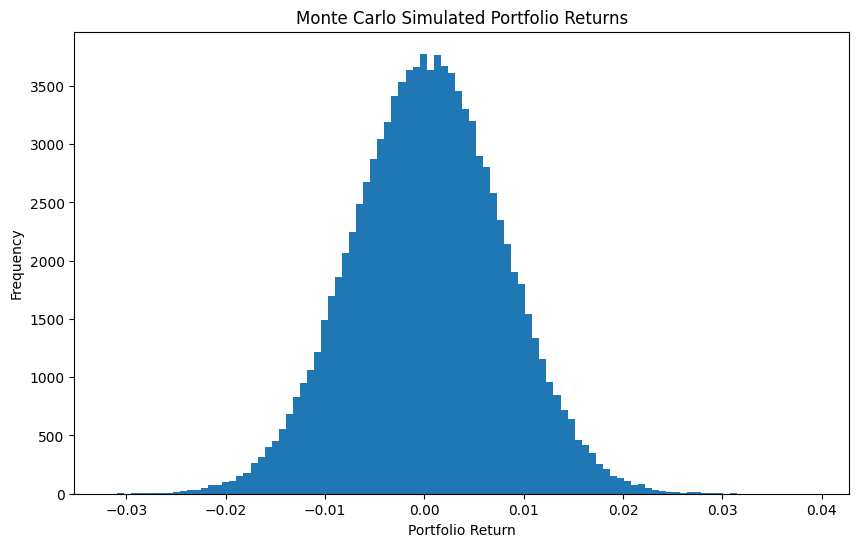

In [ ]:
#visualizing our monte-carlo simulation(for 10,000 days!)

plt.figure(figsize=(10, 6))

plt.hist(
    simulated_portfolio_returns,
    bins=100
)

plt.title("Monte Carlo Simulated Portfolio Returns")
plt.xlabel("Portfolio Return")
plt.ylabel("Frequency")

plt.show()

In [ ]:
#statistics for our simulation

print("Mean", simulated_portfolio_returns.mean())
print("Std Dev", simulated_portfolio_returns.std())

Mean 0.00036615858459762085
Std Dev 0.007536125031468318
